# Import Libraries and read data 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('raw_data.csv')

In [3]:
df.head()

,Timestamp,age,sleep_duration,water_intake,stress,screentime,illness
0,23/03/2026 14:16:37,19,6-7,2.0,3,10.0,Yes
1,23/03/2026 14:20:19,20,5-6,3.0,6,5.0,No
2,23/03/2026 14:21:07,20,6-7,2.5,3,1.0,No
3,23/03/2026 14:22:47,20,5-6,3.0,9,4.0,Yes
4,23/03/2026 14:23:46,19,5-6,2.0,6,4.0,Yes


# Modify columns and rows of datasets

In [4]:
# drop Timestamp column
df.drop(['Timestamp'], axis=1, inplace=True)

In [5]:
# Convert yes and no in column illness to 1 and 0
df['illness'] = df['illness'].map({'Yes': 1, 'No': 0})


In [6]:
df['sleep_duration'] = df['sleep_duration'].map({'<3': 2.5, '3-4':3.5,'4-5':4.5,'5-6':5.5,'6-7':6.5,'7-8':7.5,'>8':8.5})

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             51 non-null     int64  
 1   sleep_duration  51 non-null     float64
 2   water_intake    51 non-null     float64
 3   stress          51 non-null     int64  
 4   screentime      51 non-null     float64
 5   illness         51 non-null     int64  
dtypes: float64(3), int64(3)
memory usage: 2.5 KB


In [8]:
df.head()

,age,sleep_duration,water_intake,stress,screentime,illness
0,19,6.5,2.0,3,10.0,1
1,20,5.5,3.0,6,5.0,0
2,20,6.5,2.5,3,1.0,0
3,20,5.5,3.0,9,4.0,1
4,19,5.5,2.0,6,4.0,1


# Data preprocessing

In [9]:

# Check for missing values
df.isnull().sum()

age               0
sleep_duration    0
water_intake      0
stress            0
screentime        0
illness           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

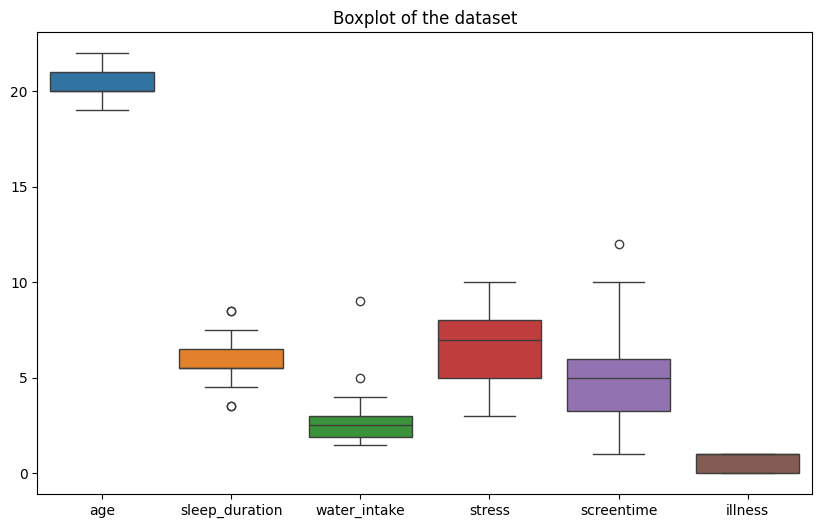

In [11]:
# check for outliers using boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title('Boxplot of the dataset')
plt.show()
# remove outliers in columns sleep_duration and screentime using IQR method
Q1 = df[['sleep_duration','water_intake', 'screentime']].quantile(0.25)
Q3 = df[['sleep_duration','water_intake', 'screentime']].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df[['sleep_duration','water_intake', 'screentime']] < (Q1 - 1.5 * IQR)) | (df[['sleep_duration','water_intake', 'screentime']] > (Q3 + 1.5 * IQR))).any(axis=1)]


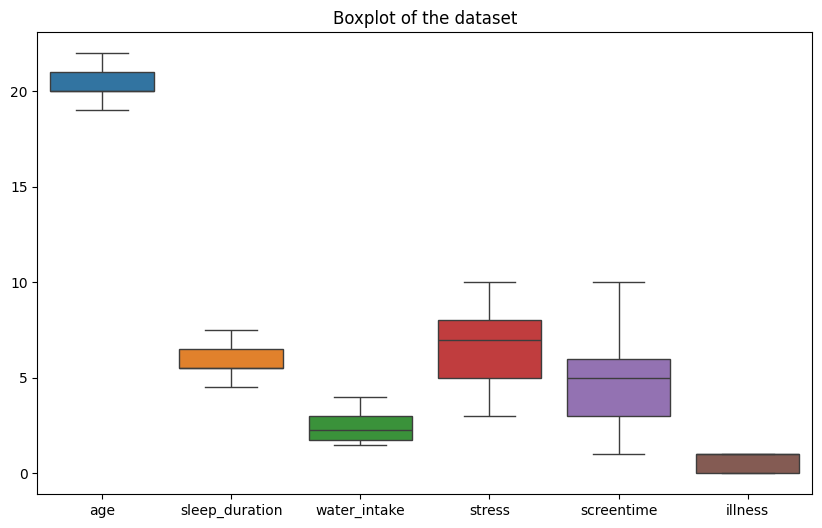

In [12]:
# check for outliers and remove them 
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title('Boxplot of the dataset')
plt.show()

In [13]:
# Shape after removing outliers
df.shape

(44, 6)

In [14]:
# descriptive statistics
df.describe()

,age,sleep_duration,water_intake,stress,screentime,illness
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,20.227273,6.068182,2.313636,6.636364,4.954545,0.545455
std,0.858978,0.899554,0.659665,1.713027,2.185625,0.503686
min,19.000000,4.500000,1.500000,3.000000,1.000000,0.000000
25%,20.000000,5.500000,1.725000,5.000000,3.000000,0.000000
50%,20.000000,5.500000,2.250000,7.000000,5.000000,1.000000
75%,21.000000,6.500000,3.000000,8.000000,6.000000,1.000000
max,22.000000,7.500000,4.000000,10.000000,10.000000,1.000000


# EDA

C:\Users\chhay\AppData\Local\Temp\ipykernel_20680\3877598424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age', data=df, palette='Set1')


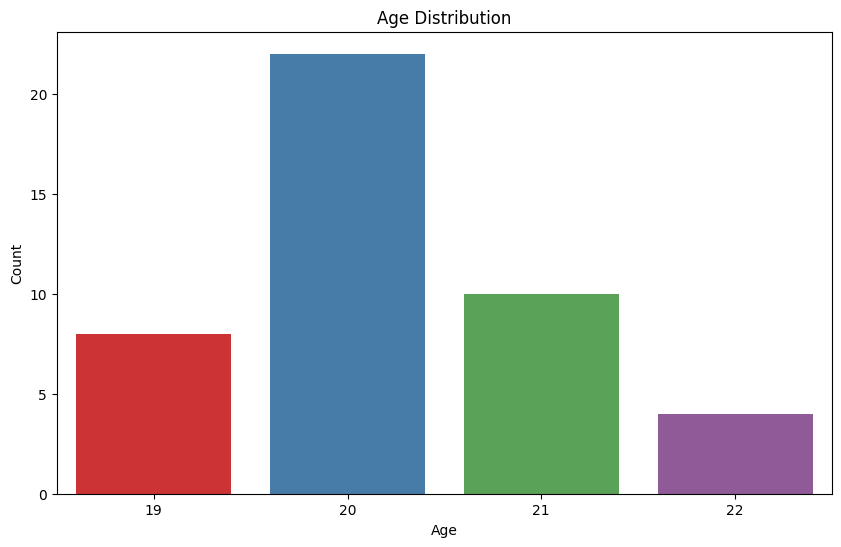

In [15]:
# age distribution barplots bin 19,20,21,22,23 and apply color palette set 1. y is count of each age group
plt.figure(figsize=(10,6))
sns.countplot(x='age', data=df, palette='Set1')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


C:\Users\chhay\AppData\Local\Temp\ipykernel_20680\2307686494.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['stress'].value_counts().index, y=df['stress'].value_counts(),palette='Set2')


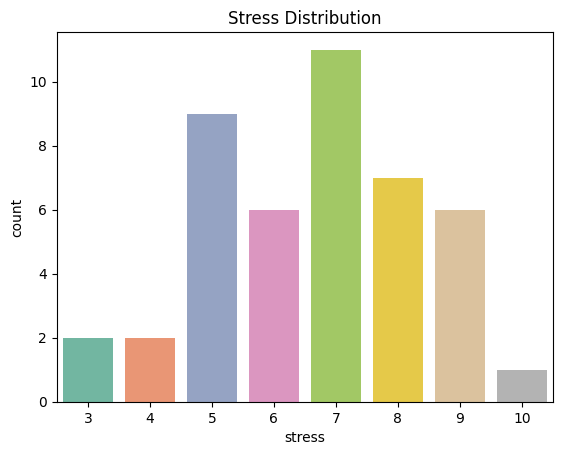

In [16]:
# Count Plots (Bar Charts) of stress
sns.barplot(x=df['stress'].value_counts().index, y=df['stress'].value_counts(),palette='Set2')
plt.title('Stress Distribution')
plt.show()

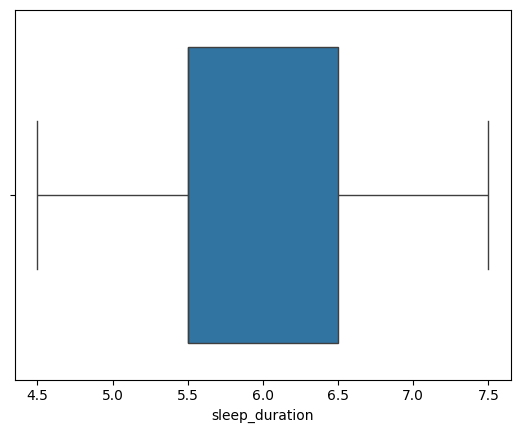

In [17]:
# boxplots sleep_duration
sns.boxplot(x=df['sleep_duration'])
plt.show()

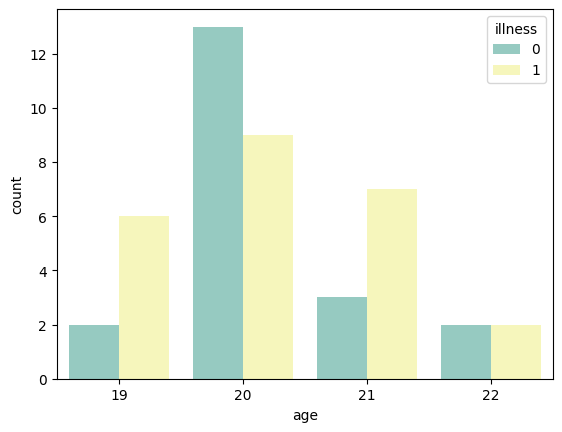

In [18]:
# group barchart : age vs illness (1 and 0)
sns.countplot(x='age', hue='illness', data=df, palette='Set3')
plt.show()

C:\Users\chhay\AppData\Local\Temp\ipykernel_20680\1914672590.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='illness', y='screentime', data=df, palette='Set2')


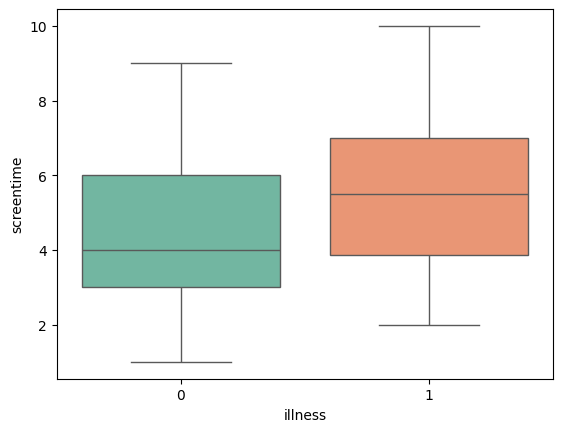

In [19]:
# plot illness vs screentime
sns.boxplot(x='illness', y='screentime', data=df, palette='Set2')
plt.show()

# Build model 

In [20]:
# Shuffle data before splitting, and use named columns 
feature_cols = ['age', 'sleep_duration', 'water_intake', 'stress', 'screentime']
X = df[feature_cols].to_numpy()
y = df['illness'].to_numpy()

# Shuffle before splitting to avoid ordering bias
np.random.seed(42)
indices = np.random.permutation(len(X))
X, y = X[indices], y[indices]

# Split into training and testing sets (80/20)
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(35, 5)
(9, 5)
(35,)
(9,)


In [21]:
# Feature scaling 
mean_X_train = np.mean(X_train, axis=0)
std_X_train = np.std(X_train, axis=0)
X_scaled = (X_train - mean_X_train) / std_X_train

X_new = np.concatenate((np.ones((X_scaled.shape[0], 1)), X_scaled), axis=1)

# scale the test set using training mean/std 
X_test_scaled = (X_test - mean_X_train) / std_X_train
X_test_new = np.concatenate((np.ones((X_test_scaled.shape[0], 1)), X_test_scaled), axis=1)


In [22]:
# Logistic Regression
def hypothesis(theta, X):
    return np.matmul(X, theta)

def sigmoid(z):
    return 1 / (1+ np.exp(-z))

def cost(X, y, theta):
    z = hypothesis(theta, X)
    h = sigmoid(z)
    m = len(y)
    c = (1/m) * ((-y*np.log(h) - (1-y)*np.log(1-h)).sum())
    return c

def gradient(X, y, theta):
    z = hypothesis(theta, X)
    h = sigmoid(z)
    m = len(y)
    grad = (1/m) * np.dot(X.T, (h-y))
    return grad


In [23]:
# make sure target vectors are column vectors
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# training
theta = np.zeros((X_new.shape[1], 1))
lr = 0.1

for i in range(1, 1001):
    z = hypothesis(theta, X_new)
    h = sigmoid(z)
    c = cost(X_new, y_train, theta)
    grad = gradient(X_new, y_train, theta)

    theta = theta - lr * grad

    print(f'Iteration: {i}, Cost: {c:.4f}')

Iteration: 1, Cost: 0.6931
Iteration: 2, Cost: 0.6830
Iteration: 3, Cost: 0.6736
Iteration: 4, Cost: 0.6649
Iteration: 5, Cost: 0.6567
Iteration: 6, Cost: 0.6491
Iteration: 7, Cost: 0.6420
Iteration: 8, Cost: 0.6354
Iteration: 9, Cost: 0.6292
Iteration: 10, Cost: 0.6234
Iteration: 11, Cost: 0.6180
Iteration: 12, Cost: 0.6129
Iteration: 13, Cost: 0.6081
Iteration: 14, Cost: 0.6036
Iteration: 15, Cost: 0.5994
Iteration: 16, Cost: 0.5954
Iteration: 17, Cost: 0.5917
Iteration: 18, Cost: 0.5881
Iteration: 19, Cost: 0.5848
Iteration: 20, Cost: 0.5816
Iteration: 21, Cost: 0.5786
Iteration: 22, Cost: 0.5757
Iteration: 23, Cost: 0.5730
Iteration: 24, Cost: 0.5704
Iteration: 25, Cost: 0.5680
Iteration: 26, Cost: 0.5656
Iteration: 27, Cost: 0.5634
Iteration: 28, Cost: 0.5613
Iteration: 29, Cost: 0.5593
Iteration: 30, Cost: 0.5573
Iteration: 31, Cost: 0.5555
Iteration: 32, Cost: 0.5537
Iteration: 33, Cost: 0.5520
Iteration: 34, Cost: 0.5504
Iteration: 35, Cost: 0.5488
Iteration: 36, Cost: 0.5473
I

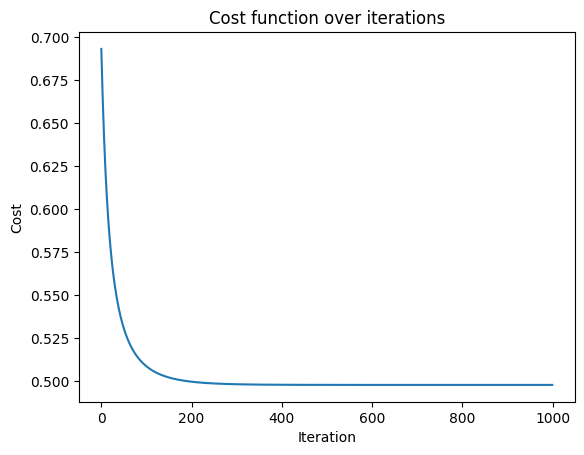

In [24]:
# Plot cost function using y_train 
theta_plot = np.zeros((X_new.shape[1], 1))
costs = []
for i in range(1, 1001):
    z = hypothesis(theta_plot, X_new)
    h = sigmoid(z)
    c = cost(X_new, y_train, theta_plot)  
    grad = gradient(X_new, y_train, theta_plot)  

    theta_plot = theta_plot - lr * grad

    costs.append(c)
plt.plot(costs)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost function over iterations')
plt.show()

# Evaluation and result

In [25]:
#Evaluate on TEST SET (X_test_new)
h_test = sigmoid(hypothesis(theta, X_test_new))
y_pred_test = h_test.copy()
y_pred_test[h_test>=0.5] = 1
y_pred_test[h_test<0.5] = 0
accuracy = np.mean(y_pred_test == y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Also show training accuracy for reference
h_train = sigmoid(hypothesis(theta, X_new))
y_pred_train = h_train.copy()
y_pred_train[h_train>=0.5] = 1
y_pred_train[h_train<0.5] = 0
train_accuracy = np.mean(y_pred_train == y_train)
print(f"Train Accuracy: {train_accuracy * 100:.2f}%")

Test Accuracy: 66.67%
Train Accuracy: 74.29%


In [26]:
# Compute precision, recall, f1-score on TEST SET
TP = np.sum((y_pred_test == 1) & (y_test == 1))
FP = np.sum((y_pred_test == 1) & (y_test == 0))
TN = np.sum((y_pred_test == 0) & (y_test == 0))
FN = np.sum((y_pred_test == 0) & (y_test == 1))
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

Precision: 0.5714
Recall: 1.0000
F1 Score: 0.7273


In [27]:
# def predict function
def predict(X, theta):
    X_scaled = (X - mean_X_train) / std_X_train
    X_new = np.concatenate((np.ones((X_scaled.shape[0], 1)), X_scaled), axis=1)
    z = hypothesis(theta, X_new)
    h = sigmoid(z)
    y_pred = h.copy()
    y_pred[h>=0.5] = 1
    y_pred[h<0.5] = 0
    return y_pred


In [28]:
# example of using predict function by giving age, sleep_duration, water_intake, stress, screentime
new_data = np.array([[22, 7.5, 2, 1, 3]])
prediction = predict(new_data, theta)
print(f"Predicted illness: {prediction[0][0]}")


Predicted illness: 0.0
